In [1]:
!pip install torch torchvision torchaudio

  Using cached torchvision-0.26.0-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
Using cached torchvision-0.26.0-cp312-cp312-win_amd64.whl (4.3 MB)


In [2]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error

# PyTorch
import torch
import torch.nn as nn

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load dataset
df = pd.read_csv("jena_climate_2009_2016.csv")

# Select relevant features
df = df[["T (degC)", "p (mbar)", "rho (g/m**3)"]]

df.head()

,T (degC),p (mbar),rho (g/m**3)
0,-8.02,996.52,1307.75
1,-8.41,996.57,1309.80
2,-8.51,996.53,1310.24
3,-8.31,996.51,1309.19
4,-8.27,996.51,1309.00


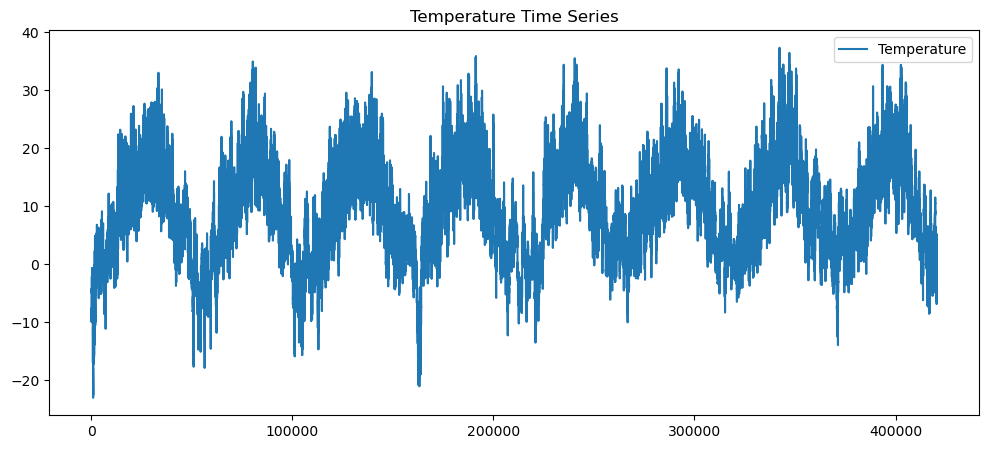

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df["T (degC)"], label="Temperature")
plt.title("Temperature Time Series")
plt.legend()
plt.show()

In [6]:
scaler = StandardScaler()
data = scaler.fit_transform(df.values)

In [7]:
def create_sequences(data, seq_len=24):
    X, y = [], []
    
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, 0])  # predict temperature
    
    return np.array(X), np.array(y)

X, y = create_sequences(data)

print("Shape:", X.shape)

Shape: (420527, 24, 3)


In [8]:
def quantum_feature_map(X):
    # Map each feature → sin & cos space
    return np.concatenate([np.sin(X), np.cos(X)], axis=2)

X_encoded = quantum_feature_map(X)

print("Encoded Shape:", X_encoded.shape)

Encoded Shape: (420527, 24, 6)


In [9]:
split = int(0.8 * len(X_encoded))

X_train, X_test = X_encoded[:split], X_encoded[split:]
y_train, y_test = y[:split], y[split:]

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [11]:
class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model=64):
        super().__init__()
        self.embedding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=4)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(d_model, 1)
    
    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])

In [12]:
def train_model(model, X_train, y_train, epochs=20):
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        output = model(X_train).squeeze()
        loss = criterion(output, y_train)

        loss.backward()
        optimizer.step()

        if epoch % 5 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    return model

In [13]:
def evaluate(model, X_test, y_test):
    model.eval()
    
    X_test = torch.tensor(X_test, dtype=torch.float32)
    preds = model(X_test).detach().numpy().flatten()

    mape = mean_absolute_percentage_error(y_test, preds)
    
    print("MAPE:", mape)
    
    return preds

In [ ]:
lstm_model = LSTMModel(input_size=X_train.shape[2])

lstm_model = train_model(lstm_model, X_train, y_train)

lstm_preds = evaluate(lstm_model, X_test, y_test)

In [ ]:
transformer_model = TransformerModel(input_size=X_train.shape[2])

transformer_model = train_model(transformer_model, X_train, y_train)

transformer_preds = evaluate(transformer_model, X_test, y_test)

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test[:200], label="True")
plt.plot(lstm_preds[:200], label="LSTM")
plt.plot(transformer_preds[:200], label="Transformer")

plt.legend()
plt.title("Model Comparison")
plt.show()

In [ ]:
print("LSTM MAPE:", mean_absolute_percentage_error(y_test, lstm_preds))
print("Transformer MAPE:", mean_absolute_percentage_error(y_test, transformer_preds))